# Cross-ply and sandwich plates under a sinusoidal pressure: Pagano (1970)

N. J. Pagano, *Exact solutions for rectangular bidirectional composites and sandwich plates*, Journal of Composite Materials 4 (1970) 20-34, https://doi.org/10.1177/002199837000400102.

Simply supported ("pinned") rectangular plates of orthotropic layers under the bidirectional sinusoidal pressure $q = q_0 \sin(\pi x/a) \sin(\pi y/b)$ on the top face, $S = a/h$ = 2, 4, 10, 20, 50 and 100:

- case (2), square $[0/90/0]$ plate with layers of equal thickness (Table 1), and case (3), the same laminate with $b = 3a$ (Table 2), of the material of Eq. (38): $E_L = 25 \times 10^6$, $E_T = 10^6$, $G_{LT} = 0.5 \times 10^6$, $G_{TT} = 0.2 \times 10^6$ psi, $\nu_{LT} = \nu_{TT} = 0.25$, 0 deg along $x$;
- the square sandwich of Table 3: faces of thickness $h/10$ of the material of Eq. (38) with the fibres along $x$, and the core of Eq. (40), $E_x = E_y = 0.04 \times 10^6$, $E_z = 0.5 \times 10^6$, $G_{xz} = G_{yz} = 0.06 \times 10^6$, $G_{xy} = 0.016 \times 10^6$ psi, $\nu_{xy} = \nu_{xz} = \nu_{yz} = 0.25$ (Pagano's $\nu_{zx} = \nu_{zy} = 0.25$);
- reference: the exact 3D elasticity solution, with the normalizations of Eq. (39), $\bar{w} = 100 E_T w(a/2, b/2, 0)/(q_0 h S^4)$, $\bar\tau_{xz} = \tau_{xz}(0, b/2, 0)/(q_0 S)$, $\bar\tau_{yz} = \tau_{yz}(a/2, 0, 0)/(q_0 S)$.

Pagano's tables give the stresses and, for case (3) only, the deflection; the deflections of the square plates are computed with the exact solution, `pagano1970.py`, which reproduces all the printed values.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from composites import laminated_plate

import scf_validation_utils as su
from scf_validation_utils import pct, markdown_table
from pagano1970 import Pagano1970, PAGANO_CORE, E_T, normalized, orthotropic_C, ply_C

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'

## The exact solution

`pagano1970.py` writes Pagano's displacement field, $u = U(z) \cos px \sin qy$, $v = V(z) \sin px \cos qy$, $w = W(z) \sin px \sin qy$, with $p = \pi/a$ and $q = \pi/b$, as the first-order system $X' = A X$ of the amplitudes $X = \{U, V, W, T_{xz}, T_{yz}, S_z\}$ of the displacements and of the transverse stresses, integrated exactly with the matrix exponential of each layer. The continuity at the interfaces and the traction conditions of the faces are then satisfied exactly, also for the isotropic layers of Pagano's Eqs. (32)-(34).

The solution reproduces all the values of Tables 1-3 of the paper within one unit of the last printed digit; two values, $\bar\sigma_x$ = .590 of Table 1 at $S = 10$ (0.5906) and $\bar\sigma_y$ = .0700 of Table 3 at $S = 20$ (0.07007), differ by slightly more than half a unit, all the others rounding correctly. Normalized stresses $\bar\sigma_x = \sigma_x/(q_0 S^2)$, $\bar\sigma_y = \sigma_y/(q_0 S^2)$, $\bar\tau_{xy} = \tau_{xy}/(q_0 S^2)$, at $z/h$ = 1/2 or 0 as indicated; the column "units" gives the largest difference in units of the last printed digit.

In [2]:
from decimal import Decimal


def units(value, printed):
    return abs(value - float(printed))/10.**Decimal(printed).as_tuple().exponent


def three_ply(S, b_a):
    h = 1./S
    return Pagano1970(1., b_a, [ply_C(0), ply_C(90), ply_C(0)], [h/3]*3)


def sandwich(S):
    h = 1./S
    return Pagano1970(1., 1., [ply_C(0), orthotropic_C(**PAGANO_CORE), ply_C(0)], [h/10, 0.8*h, h/10])


tables = []
for title, data, names in (
        ('Table 1, square [0/90/0]', su.PAGANO_TABLE_1,
         ['$\\bar\\sigma_x(a/2, b/2, 1/2)$', '$\\bar\\tau_{xz}(0, b/2, 0)$', '$\\bar\\tau_{yz}(a/2, 0, 0)$']),
        ('Table 2, [0/90/0], b = 3a', su.PAGANO_TABLE_2,
         ['$\\bar\\sigma_x(a/2, b/2, 1/2)$', '$\\bar\\tau_{xz}(0, b/2, 0)$', '$\\bar\\tau_{yz}(a/2, 0, 0)$', '$\\bar{w}(a/2, b/2, 0)$']),
        ('Table 3, square sandwich', su.PAGANO_TABLE_3,
         ['$\\bar\\sigma_x(a/2, b/2, 1/2)$', '$|\\bar\\sigma_y(a/2, b/2, 1/2)|$', '$\\bar\\tau_{xz}(0, b/2, 0)$',
          '$\\bar\\tau_{yz}(a/2, 0, 0)$', '$|\\bar\\tau_{xy}(0, 0, 1/2)|$'])):
    rows = []
    worst = 0.
    for S, printed in data.items():
        if 'Table 1' in title:
            sol = three_ply(S, 1.)
        elif 'Table 2' in title:
            sol = three_ply(S, 3.)
        else:
            sol = sandwich(S)
        wbar, st = normalized(sol, S)
        a, b = sol.a, sol.b
        top, txz, tyz, corner = st(a/2, b/2, 0.5), st(0, b/2, 0), st(a/2, 0, 0), st(0, 0, 0.5)
        if 'Table 3' in title:
            values = [top[0], abs(top[1]), txz[2], tyz[3], abs(corner[4])]
        else:
            values = [top[0], txz[2], tyz[3]] + ([wbar(a/2, b/2)] if 'Table 2' in title else [])
        u = max(units(v, p) for v, p in zip(values, printed))
        worst = max(worst, u)
        rows.append([S] + ['%s / %.5f' % (p, v) for p, v in zip(printed, values)] + ['%.2f' % u])
    display(Markdown('**%s**: printed / `pagano1970.py`' % title))
    display(Markdown(markdown_table(['$S$'] + names + ['units'], rows)))
    tables.append(worst)
print('largest difference to the printed values: %.2f units of the last digit' % max(tables))

**Table 1, square [0/90/0]**: printed / `pagano1970.py`

| $S$ | $\bar\sigma_x(a/2, b/2, 1/2)$ | $\bar\tau_{xz}(0, b/2, 0)$ | $\bar\tau_{yz}(a/2, 0, 0)$ | units |
|---|---|---|---|---|
| 4 | .801 / 0.80084 | .256 / 0.25590 | .2172 / 0.21718 | 0.19 |
| 10 | .590 / 0.59059 | .357 / 0.35731 | .1228 / 0.12275 | 0.59 |
| 20 | .552 / 0.55239 | .385 / 0.38460 | .0938 / 0.09377 | 0.40 |
| 50 | .541 / 0.54092 | .393 / 0.39338 | .0842 / 0.08424 | 0.40 |
| 100 | .539 / 0.53926 | .395 / 0.39469 | .0828 / 0.08282 | 0.31 |

**Table 2, [0/90/0], b = 3a**: printed / `pagano1970.py`

| $S$ | $\bar\sigma_x(a/2, b/2, 1/2)$ | $\bar\tau_{xz}(0, b/2, 0)$ | $\bar\tau_{yz}(a/2, 0, 0)$ | $\bar{w}(a/2, b/2, 0)$ | units |
|---|---|---|---|---|---|
| 2 | 2.13 / 2.13308 | .257 / 0.25709 | .0668 / 0.06678 | 8.17 / 8.16585 | 0.41 |
| 4 | 1.14 / 1.14430 | .351 / 0.35108 | .0334 / 0.03336 | 2.82 / 2.82113 | 0.43 |
| 10 | .726 / 0.72598 | .420 / 0.42014 | .0152 / 0.01524 | .919 / 0.91891 | 0.37 |
| 20 | .650 / 0.64998 | .434 / 0.43441 | .0119 / 0.01194 | .610 / 0.60954 | 0.46 |
| 50 | .628 / 0.62759 | .439 / 0.43869 | .0110 / 0.01098 | .520 / 0.52048 | 0.48 |
| 100 | .624 / 0.62435 | .439 / 0.43932 | .0108 / 0.01084 | .508 / 0.50766 | 0.36 |

**Table 3, square sandwich**: printed / `pagano1970.py`

| $S$ | $\bar\sigma_x(a/2, b/2, 1/2)$ | $|\bar\sigma_y(a/2, b/2, 1/2)|$ | $\bar\tau_{xz}(0, b/2, 0)$ | $\bar\tau_{yz}(a/2, 0, 0)$ | $|\bar\tau_{xy}(0, 0, 1/2)|$ | units |
|---|---|---|---|---|---|---|
| 2 | 3.278 / 3.27808 | .4517 / 0.45173 | .185 / 0.18480 | .1399 / 0.13986 | .2403 / 0.24028 | 0.41 |
| 4 | 1.556 / 1.55585 | .2595 / 0.25949 | .239 / 0.23867 | .1072 / 0.10719 | .1437 / 0.14366 | 0.40 |
| 10 | 1.153 / 1.15312 | .1104 / 0.11044 | .300 / 0.29978 | .0527 / 0.05269 | .0707 / 0.07067 | 0.42 |
| 20 | 1.110 / 1.10977 | .0700 / 0.07007 | .317 / 0.31736 | .0361 / 0.03607 | .0511 / 0.05101 | 0.93 |
| 50 | 1.099 / 1.09898 | .0569 / 0.05692 | .323 / 0.32313 | .0306 / 0.03057 | .0446 / 0.04461 | 0.34 |
| 100 | 1.098 / 1.09750 | .0550 / 0.05496 | .324 / 0.32400 | .0297 / 0.02974 | .0437 / 0.04366 | 0.50 |

largest difference to the printed values: 0.93 units of the last digit


## panels model

The plates are modelled by `su.make_shell`, a `panels.shell.Shell` with the Donnell plate models `plate_clpt_donnell`, `plate_fsdt_donnell` and `plate_tsdt_donnell`, $14 \times 14$ terms, and the hard simple support (SS-1) on the four edges, `bcs='SSSS'`: $w = 0$ and the tangential displacement and rotation zero, the normal displacement free, which are Pagano's edge conditions $\sigma_x = v = w = 0$ at $x = 0, a$ and $\sigma_y = u = w = 0$ at $y = 0, b$. The load is the sinusoidal pressure, a callable passed to `Shell.add_pressure_load`:

```python
s.add_pressure_load(lambda x, y: q0*np.sin(np.pi*x/a)*np.sin(np.pi*y/b))
c = solve(s.calc_kC(), s.calc_fext())
```

The equivalent single-layer models apply the load at the mid-surface. They are:

- `CLPT`: classical laminated plate theory;
- `FSDT-<ID>`: first-order theory with the transverse shear stiffness given by `Shell.fsdt_shear_correction`: `K1`, $\kappa = 1$ (`None`); `K56`, $\kappa = 5/6$ (the float `5/6` multiplying $\bar{A}_{ts}$); `VLA`, `'vlachoutsis'`; `ROH`, `'rohwer'`, the default of panels; `BB`, `'birman_bert'`; `TSF`, `'thickness_shear'`, the factors that reproduce the first thickness-shear frequencies, which need the densities of the plies: $\rho = 1$ for the $[0/90/0]$ plates and $\rho_f/\rho_c = 1600/80$ for the sandwich, a typical ratio, since Pagano gives none;
- `TSDT`: third-order theory of Reddy, without shear correction.

The transverse shear stresses of the FSDT are recovered from its shear forces with the equilibrium distribution of Rohwer (1988), `Laminate.calc_transverse_shear_stress(z, Qy, Qx)` of `composites`, at the points of Pagano's tables, $\tau_{xz}(0, b/2, 0)$ and $\tau_{yz}(a/2, 0, 0)$, with the shear forces `Qx`, `Qy` of `Shell.stress`.

In [3]:
PLY = (25e6, 1e6, 0.25, 0.5e6, 0.5e6, 0.2e6)  # Eq. (38), (E11, E22, nu12, G12, G13, G23), psi
CORE = tuple(PAGANO_CORE[k] for k in ('E1', 'E2', 'nu12', 'G12', 'G13', 'G23'))  # Eq. (40)
SLENDERNESS = [2, 4, 10, 20, 50, 100]
SCFS = ['K1', 'K56', 'VLA', 'ROH', 'BB', 'TSF']
CASES = {'square': 1., 'b = 3a': 3., 'sandwich': 1.}  # case: b/a
M = 14
Q0 = 1.


def laminate(case, h):
    r'''(stack, plyts, laminaprops, rhos) of panels and the 3D stiffnesses of the layers, bottom to top'''
    if case == 'sandwich':
        return ([0, 0, 0], [h/10, 0.8*h, h/10], [PLY, CORE, PLY], [1600., 80., 1600.],
                [ply_C(0), orthotropic_C(**PAGANO_CORE), ply_C(0)])
    return [0, 90, 0], [h/3]*3, [PLY]*3, [1.]*3, [ply_C(0), ply_C(90), ply_C(0)]


def recovered_stresses(s, c, lam):
    r'''tau_xz(0, b/2, 0) and tau_yz(a/2, 0, 0) from the FSDT shear forces, equilibrium distribution,
    and the shear forces Qx(0, b/2) and Qy(a/2, 0)'''
    # Shell.stress returns its fields dictionary, overwritten by the next call: copy the values at once
    _, f = s.stress(c, xs=np.array([0.]), ys=np.array([s.b/2]))
    Q1 = float(f['Qy'][0]), float(f['Qx'][0])
    _, f = s.stress(c, xs=np.array([s.a/2]), ys=np.array([0.]))
    Q2 = float(f['Qy'][0]), float(f['Qx'][0])
    return (lam.calc_transverse_shear_stress(0., *Q1)[1], lam.calc_transverse_shear_stress(0., *Q2)[0],
            Q1[1], Q2[0])


def shear_forces_3d(sol):
    r'''Qx(0, b/2) and Qy(a/2, 0) of the 3D solution, Gauss-Legendre integration in each layer'''
    xi, wi = np.polynomial.legendre.leggauss(12)
    Qx = Qy = 0.
    for za, zb in zip(sol.zi[:-1], sol.zi[1:]):
        for x_, w_ in zip(xi, wi):
            z = (za + zb)/2 + x_*(zb - za)/2
            Qx += w_*(zb - za)/2*sol.stresses(0., sol.b/2, z)[4]
            Qy += w_*(zb - za)/2*sol.stresses(sol.a/2, 0., z)[3]
    return Qx, Qy


def compute():
    res = {}
    for case, b_a in CASES.items():
        for S in SLENDERNESS:
            a, b, h = 1., b_a, 1./S
            stack, plyts, lps, rhos, Cs = laminate(case, h)
            sol = Pagano1970(a, b, Cs, plyts, q0=Q0)
            wbar3d, st = normalized(sol, S)
            Qx, Qy = shear_forces_3d(sol)
            out = {'3D': dict(wbar=wbar3d(a/2, b/2), txz=st(0, b/2, 0)[2], tyz=st(a/2, 0, 0)[3], Qx=Qx, Qy=Qy)}
            lam = laminated_plate(stack, plyts=plyts, laminaprops=lps, rhos=rhos)
            for label, theory, scf in su.models(SCFS, stack, plyts, lps, rhos):
                s = su.make_shell(theory, a, b, stack, plyts, lps, rhos, scf=scf, bcs='SSSS', m=M, n=M)
                s.add_pressure_load(lambda x, y: Q0*np.sin(np.pi*x/a)*np.sin(np.pi*y/b))
                c = su.static_linear(s)
                out[label] = dict(wbar=100*E_T*su.center(s, c)/(Q0*h*S**4))
                if theory == 'fsdt':
                    k13, k23 = su.kappas(scf, stack, plyts, lps, rhos)
                    txz, tyz, Qx, Qy = recovered_stresses(s, c, lam)
                    out[label].update(kappa13=k13, kappa23=k23, txz=txz/(Q0*S), tyz=tyz/(Q0*S), Qx=Qx, Qy=Qy)
            res['%s S%d' % (case, S)] = out
    return res


res = su.run_or_load(os.path.join(RESULTS, 'pagano1970_plates.json'), compute, rerun=RERUN)
MODELS = ['CLPT'] + ['FSDT-' + k for k in SCFS] + ['TSDT']

### Shear correction factors

$\kappa_{13} = A_{55}/\bar{A}_{55}$ ($xz$) and $\kappa_{23} = A_{44}/\bar{A}_{44}$ ($yz$) of each correction, as reported by `composites`; they depend on the laminate only, not on $S$.

In [4]:
rows = []
for case in CASES:
    r = res['%s S10' % case]
    rows.append([case] + ['%.4f / %.4f' % (r['FSDT-' + k]['kappa13'], r['FSDT-' + k]['kappa23']) for k in SCFS])
display(Markdown(markdown_table(['laminate'] + ['%s, %s' % (k, su.SCF_NAMES[k]) for k in SCFS], rows)))

| laminate | K1, $\kappa = 1$ | K56, $\kappa = 5/6$ | VLA, Vlachoutsis (1992) | ROH, Rohwer (1988) | BB, Birman and Bert (2002) | TSF, thickness-shear frequency |
|---|---|---|---|---|---|---|
| square | 1.0000 / 1.0000 | 0.8333 / 0.8333 | 0.5828 / 0.8028 | 0.5828 / 0.8024 | 0.7381 / 1.1806 | 0.5302 / 0.8469 |
| b = 3a | 1.0000 / 1.0000 | 0.8333 / 0.8333 | 0.5828 / 0.8028 | 0.5828 / 0.8024 | 0.7381 / 1.1806 | 0.5302 / 0.8469 |
| sandwich | 1.0000 / 1.0000 | 0.8333 / 0.8333 | 0.4094 / 0.6720 | 0.4094 / 0.6720 | 0.4509 / 0.7386 | 0.4028 / 0.6687 |

## Central deflection

$\bar{w} = 100 E_T w(a/2, b/2, 0)/(q_0 h S^4)$, with the difference to the 3D solution in parentheses.

In [5]:
for case in CASES:
    rows = []
    for S in SLENDERNESS:
        r = res['%s S%d' % (case, S)]
        ref = r['3D']['wbar']
        rows.append([S, '%.4f' % ref] + ['%.4f (%+.1f%%)' % (r[m]['wbar'], pct(r[m]['wbar'], ref)) for m in MODELS])
    display(Markdown('**%s**' % ('sandwich, Table 3' if case == 'sandwich' else '[0/90/0], %s' % case)))
    display(Markdown(markdown_table(['$S$', '3D'] + MODELS, rows)))

**[0/90/0], square**

| $S$ | 3D | CLPT | FSDT-K1 | FSDT-K56 | FSDT-VLA | FSDT-ROH | FSDT-BB | FSDT-TSF | TSDT |
|---|---|---|---|---|---|---|---|---|---|
| 2 | 5.0954 | 0.4312 (-91.5%) | 4.4836 (-12.0%) | 5.2293 (+2.6%) | 6.5199 (+28.0%) | 6.5205 (+28.0%) | 5.1565 (+1.2%) | 6.7583 (+32.6%) | 5.1286 (+0.7%) |
| 4 | 2.0059 | 0.4312 (-78.5%) | 1.5681 (-21.8%) | 1.7758 (-11.5%) | 2.2160 (+10.5%) | 2.2160 (+10.5%) | 1.8570 (-7.4%) | 2.3323 (+16.3%) | 1.9218 (-4.2%) |
| 10 | 0.7530 | 0.4312 (-42.7%) | 0.6306 (-16.3%) | 0.6693 (-11.1%) | 0.7637 (+1.4%) | 0.7637 (+1.4%) | 0.6952 (-7.7%) | 0.7934 (+5.4%) | 0.7125 (-5.4%) |
| 20 | 0.5164 | 0.4312 (-16.5%) | 0.4821 (-6.6%) | 0.4921 (-4.7%) | 0.5174 (+0.2%) | 0.5174 (+0.2%) | 0.4993 (-3.3%) | 0.5256 (+1.8%) | 0.5041 (-2.4%) |
| 50 | 0.4451 | 0.4312 (-3.1%) | 0.4394 (-1.3%) | 0.4411 (-0.9%) | 0.4452 (+0.0%) | 0.4452 (+0.0%) | 0.4422 (-0.6%) | 0.4465 (+0.3%) | 0.4430 (-0.5%) |
| 100 | 0.4347 | 0.4312 (-0.8%) | 0.4333 (-0.3%) | 0.4337 (-0.2%) | 0.4347 (+0.0%) | 0.4347 (+0.0%) | 0.4340 (-0.2%) | 0.4351 (+0.1%) | 0.4342 (-0.1%) |

**[0/90/0], b = 3a**

| $S$ | 3D | CLPT | FSDT-K1 | FSDT-K56 | FSDT-VLA | FSDT-ROH | FSDT-BB | FSDT-TSF | TSDT |
|---|---|---|---|---|---|---|---|---|---|
| 2 | 8.1659 | 0.5034 (-93.8%) | 6.6164 (-19.0%) | 7.8184 (-4.3%) | 10.8382 (+32.7%) | 10.8377 (+32.7%) | 8.6889 (+6.4%) | 11.8045 (+44.6%) | 7.8944 (-3.3%) |
| 4 | 2.8211 | 0.5034 (-82.2%) | 2.0547 (-27.2%) | 2.3626 (-16.3%) | 3.1501 (+11.7%) | 3.1499 (+11.7%) | 2.5974 (-7.9%) | 3.4076 (+20.8%) | 2.6411 (-6.4%) |
| 10 | 0.9189 | 0.5034 (-45.2%) | 0.7531 (-18.0%) | 0.8030 (-12.6%) | 0.9314 (+1.4%) | 0.9314 (+1.4%) | 0.8415 (-8.4%) | 0.9737 (+6.0%) | 0.8622 (-6.2%) |
| 20 | 0.6095 | 0.5034 (-17.4%) | 0.5659 (-7.2%) | 0.5784 (-5.1%) | 0.6106 (+0.2%) | 0.6106 (+0.2%) | 0.5880 (-3.5%) | 0.6212 (+1.9%) | 0.5937 (-2.6%) |
| 50 | 0.5205 | 0.5034 (-3.3%) | 0.5134 (-1.4%) | 0.5154 (-1.0%) | 0.5205 (+0.0%) | 0.5205 (+0.0%) | 0.5169 (-0.7%) | 0.5222 (+0.3%) | 0.5179 (-0.5%) |
| 100 | 0.5077 | 0.5034 (-0.8%) | 0.5059 (-0.4%) | 0.5064 (-0.3%) | 0.5077 (+0.0%) | 0.5077 (+0.0%) | 0.5068 (-0.2%) | 0.5081 (+0.1%) | 0.5070 (-0.1%) |

**sandwich, Table 3**

| $S$ | 3D | CLPT | FSDT-K1 | FSDT-K56 | FSDT-VLA | FSDT-ROH | FSDT-BB | FSDT-TSF | TSDT |
|---|---|---|---|---|---|---|---|---|---|
| 2 | 22.1029 | 0.8782 (-96.0%) | 12.7259 (-42.4%) | 14.9283 (-32.5%) | 24.6055 (+11.3%) | 24.6052 (+11.3%) | 22.6260 (+2.4%) | 24.8707 (+12.5%) | 21.3360 (-3.5%) |
| 4 | 7.5962 | 0.8782 (-88.4%) | 4.1614 (-45.2%) | 4.7666 (-37.3%) | 7.8412 (+3.2%) | 7.8411 (+3.2%) | 7.2807 (-4.2%) | 7.9285 (+4.4%) | 7.0873 (-6.7%) |
| 10 | 2.2004 | 0.8782 (-60.1%) | 1.4493 (-34.1%) | 1.5604 (-29.1%) | 2.2109 (+0.5%) | 2.2109 (+0.5%) | 2.0947 (-4.8%) | 2.2309 (+1.4%) | 2.0629 (-6.2%) |
| 20 | 1.2264 | 0.8782 (-28.4%) | 1.0236 (-16.5%) | 1.0524 (-14.2%) | 1.2274 (+0.1%) | 1.2274 (+0.1%) | 1.1958 (-2.5%) | 1.2330 (+0.5%) | 1.1876 (-3.2%) |
| 50 | 0.9348 | 0.8782 (-6.1%) | 0.9016 (-3.6%) | 0.9063 (-3.1%) | 0.9349 (+0.0%) | 0.9349 (+0.0%) | 0.9297 (-0.5%) | 0.9358 (+0.1%) | 0.9284 (-0.7%) |
| 100 | 0.8924 | 0.8782 (-1.6%) | 0.8840 (-0.9%) | 0.8852 (-0.8%) | 0.8924 (+0.0%) | 0.8924 (+0.0%) | 0.8911 (-0.1%) | 0.8926 (+0.0%) | 0.8908 (-0.2%) |

Case (3), $b = 3a$, is the only case with a printed deflection: panels against the values of Table 2.

In [6]:
rows = []
for S, printed in su.PAGANO_TABLE_2.items():
    r = res['b = 3a S%d' % S]
    rows.append([S, printed[3], '%.4f' % r['3D']['wbar']]
                + ['%.3f (%+.1f%%)' % (r[m]['wbar'], pct(r[m]['wbar'], float(printed[3])))
                   for m in ('CLPT', 'FSDT-K56', 'FSDT-ROH', 'TSDT')])
display(Markdown(markdown_table(['$S$', 'Table 2', '`pagano1970.py`', 'CLPT', 'FSDT-K56', 'FSDT-ROH', 'TSDT'], rows)))

| $S$ | Table 2 | `pagano1970.py` | CLPT | FSDT-K56 | FSDT-ROH | TSDT |
|---|---|---|---|---|---|---|
| 2 | 8.17 | 8.1659 | 0.503 (-93.8%) | 7.818 (-4.3%) | 10.838 (+32.7%) | 7.894 (-3.4%) |
| 4 | 2.82 | 2.8211 | 0.503 (-82.1%) | 2.363 (-16.2%) | 3.150 (+11.7%) | 2.641 (-6.3%) |
| 10 | .919 | 0.9189 | 0.503 (-45.2%) | 0.803 (-12.6%) | 0.931 (+1.3%) | 0.862 (-6.2%) |
| 20 | .610 | 0.6095 | 0.503 (-17.5%) | 0.578 (-5.2%) | 0.611 (+0.1%) | 0.594 (-2.7%) |
| 50 | .520 | 0.5205 | 0.503 (-3.2%) | 0.515 (-0.9%) | 0.521 (+0.1%) | 0.518 (-0.4%) |
| 100 | .508 | 0.5077 | 0.503 (-0.9%) | 0.506 (-0.3%) | 0.508 (-0.1%) | 0.507 (-0.2%) |

### Summary of the differences to 3D

Statistics of the differences of the central deflection to the 3D solution, in percent, for the thick and moderately thick plates, $S \le 10$, and for all $S$.

In [7]:
for case in CASES:
    for label, Ss in (('S <= 10', [2, 4, 10]), ('all S', SLENDERNESS)):
        cols = {m: [pct(res['%s S%d' % (case, S)][m]['wbar'], res['%s S%d' % (case, S)]['3D']['wbar']) for S in Ss]
                for m in MODELS}
        display(Markdown('**%s, %s**' % (case, label)))
        display(Markdown(su.stats_table(cols)))

**square, S <= 10**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 91.5 | 70.9 | -91.5 to -42.7 |
| FSDT-K1 | 21.8 | 16.7 | -21.8 to -12.0 |
| FSDT-K56 | 11.5 | 8.4 | -11.5 to +2.6 |
| FSDT-VLA | 28.0 | 13.3 | +1.4 to +28.0 |
| FSDT-ROH | 28.0 | 13.3 | +1.4 to +28.0 |
| FSDT-BB | 7.7 | 5.4 | -7.7 to +1.2 |
| FSDT-TSF | 32.6 | 18.1 | +5.4 to +32.6 |
| TSDT | 5.4 | 3.4 | -5.4 to +0.7 |

**square, all S**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 91.5 | 38.9 | -91.5 to -0.8 |
| FSDT-K1 | 21.8 | 9.7 | -21.8 to -0.3 |
| FSDT-K56 | 11.5 | 5.2 | -11.5 to +2.6 |
| FSDT-VLA | 28.0 | 6.7 | +0.0 to +28.0 |
| FSDT-ROH | 28.0 | 6.7 | +0.0 to +28.0 |
| FSDT-BB | 7.7 | 3.4 | -7.7 to +1.2 |
| FSDT-TSF | 32.6 | 9.4 | +0.1 to +32.6 |
| TSDT | 5.4 | 2.2 | -5.4 to +0.7 |

**b = 3a, S <= 10**

...

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 93.8 | 40.5 | -93.8 to -0.8 |
| FSDT-K1 | 27.2 | 12.2 | -27.2 to -0.4 |
| FSDT-K56 | 16.3 | 6.6 | -16.3 to -0.3 |
| FSDT-VLA | 32.7 | 7.7 | +0.0 to +32.7 |
| FSDT-ROH | 32.7 | 7.7 | +0.0 to +32.7 |
| FSDT-BB | 8.4 | 4.5 | -8.4 to +6.4 |
| FSDT-TSF | 44.6 | 12.3 | +0.1 to +44.6 |
| TSDT | 6.4 | 3.2 | -6.4 to -0.1 |

**sandwich, S <= 10**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 96.0 | 81.5 | -96.0 to -60.1 |
| FSDT-K1 | 45.2 | 40.6 | -45.2 to -34.1 |
| FSDT-K56 | 37.3 | 32.9 | -37.3 to -29.1 |
| FSDT-VLA | 11.3 | 5.0 | +0.5 to +11.3 |
| FSDT-ROH | 11.3 | 5.0 | +0.5 to +11.3 |
| FSDT-BB | 4.8 | 3.8 | -4.8 to +2.4 |
| FSDT-TSF | 12.5 | 6.1 | +1.4 to +12.5 |
| TSDT | 6.7 | 5.5 | -6.7 to -3.5 |

**sandwich, all S**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 96.0 | 46.8 | -96.0 to -1.6 |
| FSDT-K1 | 45.2 | 23.8 | -45.2 to -0.9 |
| FSDT-K56 | 37.3 | 19.5 | -37.3 to -0.8 |
| FSDT-VLA | 11.3 | 2.5 | +0.0 to +11.3 |
| FSDT-ROH | 11.3 | 2.5 | +0.0 to +11.3 |
| FSDT-BB | 4.8 | 2.4 | -4.8 to +2.4 |
| FSDT-TSF | 12.5 | 3.2 | +0.0 to +12.5 |
| TSDT | 6.7 | 3.4 | -6.7 to -0.2 |

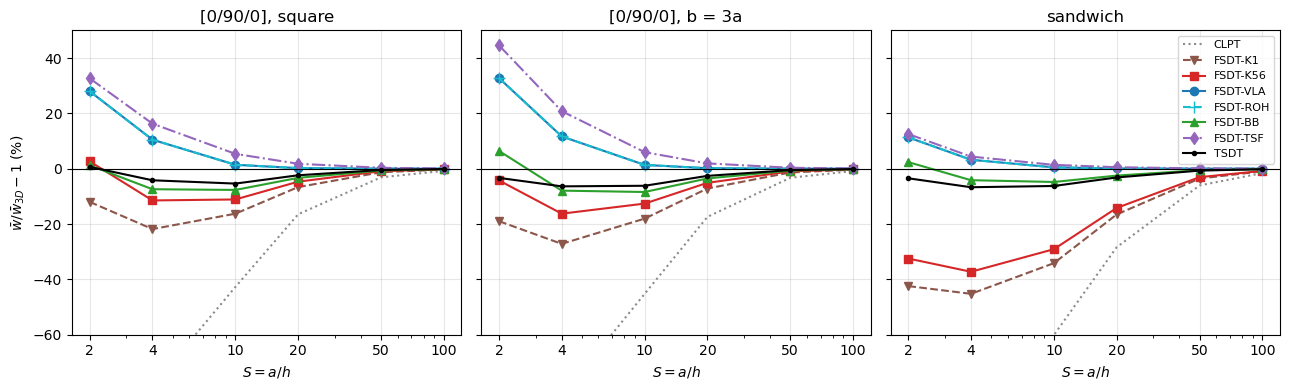

In [8]:
styles = {'CLPT': dict(color='0.55', ls=':'), 'FSDT-K1': dict(color='tab:brown', ls='--', marker='v'),
          'FSDT-K56': dict(color='tab:red', marker='s'), 'FSDT-VLA': dict(color='tab:blue', marker='o'),
          'FSDT-ROH': dict(color='tab:cyan', ls='--', marker='+', ms=9), 'FSDT-BB': dict(color='tab:green', marker='^'),
          'FSDT-TSF': dict(color='tab:purple', ls='-.', marker='d'), 'TSDT': dict(color='k', marker='.')}
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, case in zip(axes, CASES):
    for m in MODELS:
        e = [pct(res['%s S%d' % (case, S)][m]['wbar'], res['%s S%d' % (case, S)]['3D']['wbar']) for S in SLENDERNESS]
        ax.plot(SLENDERNESS, e, label=m, **styles[m])
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xscale('log')
    ax.set_xticks(SLENDERNESS)
    ax.set_xticklabels(SLENDERNESS)
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_ylim(-60, 50)
    ax.set_xlabel('$S = a/h$')
    ax.set_title('sandwich' if case == 'sandwich' else '[0/90/0], %s' % case)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('$\\bar{w}/\\bar{w}_{3D} - 1$ (%)')
axes[-1].legend(fontsize=8)
plt.tight_layout()

The CLPT, $-92\%$ to $-96\%$ for $S = 2$, is cut by the vertical limits of the figure.

## Transverse shear stresses

$\bar\tau_{xz}(0, b/2, 0)$ and $\bar\tau_{yz}(a/2, 0, 0)$ recovered from the shear forces of each FSDT with the equilibrium distribution of Rohwer, against the 3D solution (Tables 1-3 print them to three or four digits). The shear forces at the edges come from the Ritz solution of each correction, hence the differences among the corrections.

In [9]:
for comp, name in (('txz', '$\\bar\\tau_{xz}(0, b/2, 0)$'), ('tyz', '$\\bar\\tau_{yz}(a/2, 0, 0)$')):
    for case in CASES:
        rows = []
        for S in SLENDERNESS:
            r = res['%s S%d' % (case, S)]
            ref = r['3D'][comp]
            rows.append([S, '%.4f' % ref] + ['%.4f (%+.1f%%)' % (r['FSDT-' + k][comp], pct(r['FSDT-' + k][comp], ref))
                                              for k in SCFS])
        display(Markdown('**%s, %s**' % (name, 'sandwich' if case == 'sandwich' else '[0/90/0], %s' % case)))
        display(Markdown(markdown_table(['$S$', '3D'] + ['FSDT-' + k for k in SCFS], rows)))

**$\bar\tau_{xz}(0, b/2, 0)$, [0/90/0], square**

| $S$ | 3D | FSDT-K1 | FSDT-K56 | FSDT-VLA | FSDT-ROH | FSDT-BB | FSDT-TSF |
|---|---|---|---|---|---|---|---|
| 2 | 0.1640 | 0.2934 (+79.0%) | 0.2884 (+75.9%) | 0.2562 (+56.2%) | 0.2562 (+56.3%) | 0.2543 (+55.1%) | 0.2426 (+48.0%) |
| 4 | 0.2559 | 0.3400 (+32.8%) | 0.3338 (+30.4%) | 0.3107 (+21.4%) | 0.3107 (+21.4%) | 0.3174 (+24.1%) | 0.3019 (+18.0%) |
| 10 | 0.3573 | 0.3809 (+6.6%) | 0.3787 (+6.0%) | 0.3716 (+4.0%) | 0.3716 (+4.0%) | 0.3753 (+5.0%) | 0.3691 (+3.3%) |
| 20 | 0.3846 | 0.3902 (+1.4%) | 0.3895 (+1.3%) | 0.3875 (+0.8%) | 0.3875 (+0.8%) | 0.3886 (+1.0%) | 0.3868 (+0.6%) |
| 50 | 0.3934 | 0.3930 (-0.1%) | 0.3929 (-0.1%) | 0.3925 (-0.2%) | 0.3925 (-0.2%) | 0.3927 (-0.2%) | 0.3924 (-0.2%) |
| 100 | 0.3947 | 0.3934 (-0.3%) | 0.3934 (-0.3%) | 0.3933 (-0.4%) | 0.3933 (-0.4%) | 0.3933 (-0.3%) | 0.3933 (-0.4%) |

**$\bar\tau_{xz}(0, b/2, 0)$, [0/90/0], b = 3a**

| $S$ | 3D | FSDT-K1 | FSDT-K56 | FSDT-VLA | FSDT-ROH | FSDT-BB | FSDT-TSF |
|---|---|---|---|---|---|---|---|
| 2 | 0.2571 | 0.4286 (+66.7%) | 0.4273 (+66.2%) | 0.4222 (+64.2%) | 0.4222 (+64.2%) | 0.4238 (+64.8%) | 0.4201 (+63.4%) |
| 4 | 0.3511 | 0.4357 (+24.1%) | 0.4351 (+23.9%) | 0.4332 (+23.4%) | 0.4332 (+23.4%) | 0.4342 (+23.7%) | 0.4325 (+23.2%) |
| 10 | 0.4201 | 0.4386 (+4.4%) | 0.4385 (+4.4%) | 0.4382 (+4.3%) | 0.4382 (+4.3%) | 0.4384 (+4.3%) | 0.4381 (+4.3%) |
| 20 | 0.4344 | 0.4391 (+1.1%) | 0.4391 (+1.1%) | 0.4390 (+1.1%) | 0.4390 (+1.1%) | 0.4391 (+1.1%) | 0.4390 (+1.0%) |
| 50 | 0.4387 | 0.4393 (+0.1%) | 0.4392 (+0.1%) | 0.4392 (+0.1%) | 0.4392 (+0.1%) | 0.4392 (+0.1%) | 0.4392 (+0.1%) |
| 100 | 0.4393 | 0.4393 (-0.0%) | 0.4393 (-0.0%) | 0.4393 (-0.0%) | 0.4393 (-0.0%) | 0.4393 (-0.0%) | 0.4393 (-0.0%) |

**$\bar\tau_{xz}(0, b/2, 0)$, sandwich**

...

| $S$ | 3D | FSDT-K1 | FSDT-K56 | FSDT-VLA | FSDT-ROH | FSDT-BB | FSDT-TSF |
|---|---|---|---|---|---|---|---|
| 2 | 0.2591 | 0.3120 (+20.4%) | 0.3226 (+24.5%) | 0.3902 (+50.6%) | 0.3901 (+50.6%) | 0.3941 (+52.1%) | 0.4186 (+61.5%) |
| 4 | 0.2172 | 0.2145 (-1.3%) | 0.2274 (+4.7%) | 0.2758 (+27.0%) | 0.2758 (+27.0%) | 0.2617 (+20.5%) | 0.2943 (+35.5%) |
| 10 | 0.1228 | 0.1285 (+4.7%) | 0.1332 (+8.5%) | 0.1480 (+20.6%) | 0.1480 (+20.6%) | 0.1403 (+14.3%) | 0.1534 (+25.0%) |
| 20 | 0.0938 | 0.1092 (+16.4%) | 0.1105 (+17.9%) | 0.1148 (+22.4%) | 0.1148 (+22.4%) | 0.1124 (+19.8%) | 0.1163 (+24.0%) |
| 50 | 0.0842 | 0.1032 (+22.6%) | 0.1035 (+22.8%) | 0.1042 (+23.7%) | 0.1042 (+23.7%) | 0.1038 (+23.2%) | 0.1044 (+24.0%) |
| 100 | 0.0828 | 0.1024 (+23.6%) | 0.1024 (+23.7%) | 0.1026 (+23.9%) | 0.1026 (+23.9%) | 0.1025 (+23.8%) | 0.1027 (+24.0%) |

**$\bar\tau_{yz}(a/2, 0, 0)$, [0/90/0], b = 3a**

| $S$ | 3D | FSDT-K1 | FSDT-K56 | FSDT-VLA | FSDT-ROH | FSDT-BB | FSDT-TSF |
|---|---|---|---|---|---|---|---|
| 2 | 0.0668 | 0.0854 (+27.9%) | 0.0936 (+40.2%) | 0.1257 (+88.2%) | 0.1257 (+88.2%) | 0.1159 (+73.6%) | 0.1391 (+108.3%) |
| 4 | 0.0334 | 0.0410 (+22.8%) | 0.0449 (+34.5%) | 0.0568 (+70.1%) | 0.0568 (+70.1%) | 0.0504 (+51.0%) | 0.0611 (+83.2%) |
| 10 | 0.0152 | 0.0224 (+47.3%) | 0.0232 (+52.4%) | 0.0254 (+66.8%) | 0.0254 (+66.8%) | 0.0240 (+57.8%) | 0.0262 (+71.8%) |
| 20 | 0.0119 | 0.0195 (+63.0%) | 0.0197 (+64.7%) | 0.0202 (+69.4%) | 0.0202 (+69.4%) | 0.0199 (+66.4%) | 0.0204 (+71.0%) |
| 50 | 0.0110 | 0.0186 (+69.6%) | 0.0187 (+69.9%) | 0.0187 (+70.8%) | 0.0187 (+70.8%) | 0.0187 (+70.2%) | 0.0188 (+71.0%) |
| 100 | 0.0108 | 0.0185 (+70.7%) | 0.0185 (+70.8%) | 0.0185 (+71.0%) | 0.0185 (+71.0%) | 0.0185 (+70.9%) | 0.0185 (+71.1%) |

**$\bar\tau_{yz}(a/2, 0, 0)$, sandwich**

| $S$ | 3D | FSDT-K1 | FSDT-K56 | FSDT-VLA | FSDT-ROH | FSDT-BB | FSDT-TSF |
|---|---|---|---|---|---|---|---|
| 2 | 0.1399 | 0.1050 (-24.9%) | 0.1088 (-22.2%) | 0.1525 (+9.0%) | 0.1525 (+9.0%) | 0.1501 (+7.4%) | 0.1535 (+9.8%) |
| 4 | 0.1072 | 0.0702 (-34.5%) | 0.0748 (-30.2%) | 0.1096 (+2.2%) | 0.1096 (+2.2%) | 0.1059 (-1.2%) | 0.1105 (+3.1%) |
| 10 | 0.0527 | 0.0392 (-25.7%) | 0.0409 (-22.4%) | 0.0528 (+0.2%) | 0.0528 (+0.2%) | 0.0510 (-3.3%) | 0.0532 (+0.9%) |
| 20 | 0.0361 | 0.0321 (-10.9%) | 0.0326 (-9.5%) | 0.0361 (+0.2%) | 0.0361 (+0.2%) | 0.0356 (-1.4%) | 0.0363 (+0.5%) |
| 50 | 0.0306 | 0.0300 (-1.9%) | 0.0301 (-1.7%) | 0.0307 (+0.3%) | 0.0307 (+0.3%) | 0.0306 (-0.0%) | 0.0307 (+0.3%) |
| 100 | 0.0297 | 0.0297 (-0.3%) | 0.0297 (-0.2%) | 0.0298 (+0.3%) | 0.0298 (+0.3%) | 0.0298 (+0.2%) | 0.0298 (+0.3%) |

In [10]:
for case in CASES:
    for comp in ('txz', 'tyz'):
        cols = {'FSDT-' + k: [pct(res['%s S%d' % (case, S)]['FSDT-' + k][comp], res['%s S%d' % (case, S)]['3D'][comp])
                              for S in SLENDERNESS if S >= 4] for k in SCFS}
        display(Markdown('**%s, %s, $S \\ge 4$**' % (case, comp)))
        display(Markdown(su.stats_table(cols)))

**square, txz, $S \ge 4$**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| FSDT-K1 | 32.8 | 8.3 | -0.3 to +32.8 |
| FSDT-K56 | 30.4 | 7.6 | -0.3 to +30.4 |
| FSDT-VLA | 21.4 | 5.3 | -0.4 to +21.4 |
| FSDT-ROH | 21.4 | 5.4 | -0.4 to +21.4 |
| FSDT-BB | 24.1 | 6.1 | -0.3 to +24.1 |
| FSDT-TSF | 18.0 | 4.5 | -0.4 to +18.0 |

**square, tyz, $S \ge 4$**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| FSDT-K1 | 23.6 | 13.7 | -1.3 to +23.6 |
| FSDT-K56 | 23.7 | 15.5 | +4.7 to +23.7 |
| FSDT-VLA | 27.0 | 23.5 | +20.6 to +27.0 |
| FSDT-ROH | 27.0 | 23.5 | +20.6 to +27.0 |
| FSDT-BB | 23.8 | 20.3 | +14.3 to +23.8 |
| FSDT-TSF | 35.5 | 26.5 | +24.0 to +35.5 |

**b = 3a, txz, $S \ge 4$**

...

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| FSDT-K1 | 70.7 | 54.7 | +22.8 to +70.7 |
| FSDT-K56 | 70.8 | 58.5 | +34.5 to +70.8 |
| FSDT-VLA | 71.0 | 69.6 | +66.8 to +71.0 |
| FSDT-ROH | 71.0 | 69.6 | +66.8 to +71.0 |
| FSDT-BB | 70.9 | 63.3 | +51.0 to +70.9 |
| FSDT-TSF | 83.2 | 73.6 | +71.0 to +83.2 |

**sandwich, txz, $S \ge 4$**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| FSDT-K1 | 19.2 | 5.1 | -0.1 to +19.2 |
| FSDT-K56 | 17.3 | 4.6 | -0.1 to +17.3 |
| FSDT-VLA | 3.1 | 0.8 | -0.1 to +3.1 |
| FSDT-ROH | 3.1 | 0.8 | -0.1 to +3.1 |
| FSDT-BB | 4.6 | 1.2 | -0.1 to +4.6 |
| FSDT-TSF | 2.7 | 0.7 | -0.1 to +2.7 |

**sandwich, tyz, $S \ge 4$**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| FSDT-K1 | 34.5 | 14.7 | -34.5 to -0.3 |
| FSDT-K56 | 30.2 | 12.8 | -30.2 to -0.2 |
| FSDT-VLA | 2.2 | 0.7 | +0.2 to +2.2 |
| FSDT-ROH | 2.2 | 0.7 | +0.2 to +2.2 |
| FSDT-BB | 3.3 | 1.2 | -3.3 to +0.2 |
| FSDT-TSF | 3.1 | 1.0 | +0.3 to +3.1 |

The recovered $\tau_{yz}(a/2, 0, 0)$ of the $[0/90/0]$ plates remains 24% (square) and 71% ($b = 3a$) above the 3D value in the thin limit, where all corrections agree. The shear forces of the FSDT are not the cause: the next table compares the shear forces of `FSDT-ROH`, $Q_x(0, b/2)$ and $Q_y(a/2, 0)$, with the resultants of the 3D stresses, and the mid-plane stress per unit shear force, $\tau(0) h/Q$, of the 3D solution with that of the equilibrium distribution, which does not depend on $S$.

In [11]:
rows = []
for case in CASES:
    stack, plyts, lps = laminate(case, 1.)[:3]
    lam = laminated_plate(stack, plyts=plyts, laminaprops=lps)
    eq_xz = lam.calc_transverse_shear_stress(0., 0., 1.)[1]
    eq_yz = lam.calc_transverse_shear_stress(0., 1., 0.)[0]
    for S in (4, 10, 100):
        r = res['%s S%d' % (case, S)]
        d, f = r['3D'], r['FSDT-ROH']
        # tau h/Q = (tau/(q0 S)) (q0 S h)/Q, with a = 1 and h = 1/S
        rows.append([case, S, '%+.2f%%' % pct(f['Qx'], d['Qx']), '%+.2f%%' % pct(f['Qy'], d['Qy']),
                     '%.3f / %.3f' % (d['txz']/d['Qx'], eq_xz), '%.3f / %.3f' % (d['tyz']/d['Qy'], eq_yz)])
display(Markdown(markdown_table(['laminate', '$S$', '$Q_x$, FSDT-ROH vs 3D', '$Q_y$, FSDT-ROH vs 3D',
                                 '$\\tau_{xz}(0) h/Q_x$: 3D / equilibrium', '$\\tau_{yz}(0) h/Q_y$: 3D / equilibrium'], rows)))

| laminate | $S$ | $Q_x$, FSDT-ROH vs 3D | $Q_y$, FSDT-ROH vs 3D | $\tau_{xz}(0) h/Q_x$: 3D / equilibrium | $\tau_{yz}(0) h/Q_y$: 3D / equilibrium |
|---|---|---|---|---|---|
| square | 4 | -1.37% | +3.39% | 1.128 / 1.389 | 2.373 / 2.914 |
| square | 10 | +0.09% | -0.48% | 1.337 / 1.389 | 2.405 / 2.914 |
| square | 100 | +0.00% | -0.02% | 1.394 / 1.389 | 2.351 / 2.914 |
| b = 3a | 4 | -0.04% | +1.95% | 1.125 / 1.389 | 1.746 / 2.914 |
| b = 3a | 10 | +0.01% | -1.53% | 1.332 / 1.389 | 1.720 / 2.914 |
| b = 3a | 100 | +0.00% | -0.03% | 1.389 / 1.389 | 1.704 / 2.914 |
| sandwich | 4 | -0.52% | +1.22% | 1.069 / 1.108 | 1.128 / 1.139 |
| sandwich | 10 | +0.04% | -0.24% | 1.103 / 1.108 | 1.134 / 1.139 |
| sandwich | 100 | +0.00% | -0.01% | 1.109 / 1.108 | 1.136 / 1.139 |

### Through-thickness distributions

The shapes of the transverse shear stresses through the thickness at $S = 10$, all scaled to the shear force $Q$ of the 3D solution, $\tau h/Q$: the 3D solution; the equilibrium distribution of Rohwer (1988), `calc_transverse_shear_stress`, which underlies the static shear correction of `'rohwer'` and is used above for the recovery; the piecewise constant distribution of the FSDT, $C_{s}^{(k)}\gamma$; and that of the TSDT, $C_{s}^{(k)}(1 - 4z^2/h^2)\gamma$. They are computed here directly, without panels.

square   xz: max |equilibrium - 3D| = 0.061 Q/h, max 3D = 1.337 Q/h
square   yz: max |equilibrium - 3D| = 0.509 Q/h, max 3D = 2.405 Q/h
sandwich xz: max |equilibrium - 3D| = 0.043 Q/h, max 3D = 1.103 Q/h
sandwich yz: max |equilibrium - 3D| = 0.014 Q/h, max 3D = 1.134 Q/h


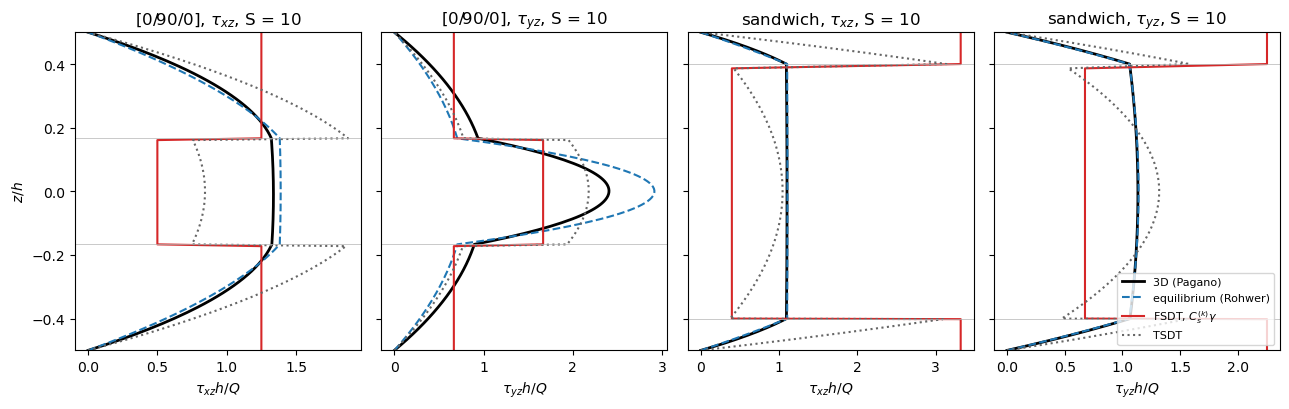

In [12]:
S = 10
a = b = 1.
h = a/S
fig, axes = plt.subplots(1, 4, figsize=(13, 4.2), sharey=True)
for i, case in enumerate(('square', 'sandwich')):
    stack, plyts, lps, rhos, Cs = laminate(case, h)
    sol = Pagano1970(a, b, Cs, plyts)
    lam = laminated_plate(stack, plyts=plyts, laminaprops=lps, shear_correction='rohwer')
    zi = -h/2 + np.concatenate(([0.], np.cumsum(plyts)))
    z = np.concatenate([np.linspace(zi[k], zi[k+1], 60) for k in range(len(plyts))])
    layer = np.minimum(np.searchsorted(zi, z, side='right') - 1, len(plyts) - 1)
    for j, (comp, x, y) in enumerate((('xz', 0., b/2), ('yz', a/2, 0.))):
        ax = axes[2*i + j]
        idx = 4 if comp == 'xz' else 3
        t3d = np.array([sol.stresses(x, y, zz)[idx] for zz in z])
        Q = np.trapezoid(t3d, z)
        if comp == 'xz':
            teq = np.array([lam.calc_transverse_shear_stress(zz, 0., Q)[1] for zz in z])
        else:
            teq = np.array([lam.calc_transverse_shear_stress(zz, Q, 0.)[0] for zz in z])
        G = np.array([Cs[k][4, 4] if comp == 'xz' else Cs[k][3, 3] for k in layer])
        fsdt = G*Q/np.trapezoid(G, z)
        shape = G*(1 - 4*z**2/h**2)
        tsdt = shape*Q/np.trapezoid(shape, z)
        ax.plot(t3d*h/Q, z/h, 'k-', lw=2, label='3D (Pagano)')
        ax.plot(teq*h/Q, z/h, color='tab:blue', ls='--', label='equilibrium (Rohwer)')
        ax.plot(fsdt*h/Q, z/h, color='tab:red', label='FSDT, $C_s^{(k)}\\gamma$')
        ax.plot(tsdt*h/Q, z/h, color='0.4', ls=':', label='TSDT')
        for zz in zi[1:-1]:
            ax.axhline(zz/h, color='0.7', lw=0.5)
        tex = '\\tau_{xz}' if comp == 'xz' else '\\tau_{yz}'
        ax.set_title('%s, $%s$, S = %d' % ('[0/90/0]' if case == 'square' else 'sandwich', tex, S))
        ax.set_xlabel('$%s h/Q$' % tex)
        print('%-8s %s: max |equilibrium - 3D| = %.3f Q/h, max 3D = %.3f Q/h'
              % (case, comp, np.abs(teq - t3d).max()*h/Q, t3d.max()*h/Q))
axes[0].set_ylabel('$z/h$')
axes[0].set_ylim(-0.5, 0.5)
axes[-1].legend(fontsize=8, loc='lower right')
plt.tight_layout()

## Discussion

- **Exact solution.** `pagano1970.py` reproduces every value of Tables 1-3 of Pagano (1970) within 0.93 units of the last printed digit, which validates the 3D reference, including the deflections of the square plates and of the sandwich that the paper does not print.
- **Thin limit.** For $S \ge 50$ all models but the CLPT are within 1.4% of the 3D deflection for the $[0/90/0]$ plates and 3.6% for the sandwich; `FSDT-ROH` and `FSDT-VLA` are the closest, within 0.05%. At $S = 20$ they are within 0.2% for the three laminates, against $-4.7\%$ to $-5.1\%$ of `FSDT-K56` for the $[0/90/0]$ plates and $-14.2\%$ for the sandwich.
- **Static corrections.** `'rohwer'` and `'vlachoutsis'` give the same factors ($\kappa_{13}, \kappa_{23}$ = 0.5828, 0.802 for $[0/90/0]$, 0.4094, 0.6720 for the sandwich) and deflections within 0.01%. They are the best FSDT for $S \ge 10$: +1.4% at $S = 10$ for both $[0/90/0]$ plates and +0.5% for the sandwich. For the thick plates they overestimate the deflection, +10.5% to +11.7% at $S = 4$ and +28% to +33% at $S = 2$ for $[0/90/0]$, +3.2% and +11.3% for the sandwich, since the transverse normal strain and the warping of the thick plates are outside the FSDT.
- **Constant factors.** $\kappa = 5/6$ is $-11.1\%$ ($S = 10$) to $-11.5\%$ ($S = 4$) off for the square $[0/90/0]$ plate and $-12.6\%$ to $-16.3\%$ for $b = 3a$; for the sandwich, whose shear stiffness $\bar{A}_{ts}$ is dominated by the faces, it is $-29\%$ to $-37\%$ off for $S \le 10$ and still $-14\%$ at $S = 20$. $\kappa = 1$ is worse in all cases. Its value $+2.6\%$ at $S = 2$ for the square plate is a compensation of errors.
- **Other corrections.** `'birman_bert'` ($\kappa_{23} = 1.18$ for $[0/90/0]$) is within $-7.7\%$ to $+1.2\%$ (square), $-8.4\%$ to $+6.4\%$ ($b = 3a$) and $-4.8\%$ to $+2.4\%$ (sandwich) for $S \le 10$, the smallest maximum error of the FSDT for the thick plates, but it is $-3.3\%$ to $-3.5\%$ off at $S = 20$ for $[0/90/0]$ where the static corrections are exact. `'thickness_shear'` is the most flexible: $+5.4\%$ to $+6.0\%$ at $S = 10$ for $[0/90/0]$ and +1.4% for the sandwich.
- **TSDT.** The third-order theory, with its single parabola through the thickness, is within $-6.7\%$ to $+0.7\%$ for all $S$, but it does not converge to the 3D solution as fast as the static corrections: $-5.4\%$ to $-6.2\%$ at $S = 10$ and $-2.4\%$ to $-3.2\%$ at $S = 20$.
- **Transverse shear stresses.** The recovery with the equilibrium distribution of Rohwer from the FSDT shear forces gives $\tau_{xz}(0, b/2, 0)$ within 1.1% of 3D for $S \ge 20$ and within +4.0% (square), +4.3% ($b = 3a$) and +0.5% (sandwich) at $S = 10$ with `FSDT-ROH`; for $S \le 4$ the 3D distribution is no longer the one of the cylindrical bending, $+21\%$ to $+64\%$ at $S = 2$-4 for $[0/90/0]$. For the sandwich, `FSDT-ROH` recovers both shear stresses within 0.5% for $S \ge 10$ and 3.1% at $S = 4$; $\kappa = 1$ and $5/6$ give $\tau_{yz}$ 22% to 35% too low for $S \le 10$. For $[0/90/0]$, $\tau_{yz}(a/2, 0, 0)$ remains 24% (square) and 71% ($b = 3a$) too high even in the thin limit, for all corrections, although the shear force $Q_y$ of the FSDT agrees with the 3D resultant within 0.03% at $S = 100$: the 3D distribution of $\tau_{yz}$, with the stiff 90 deg ply in the middle, is not the one of the cylindrical bending assumed by the equilibrium approach ($\tau_{yz}(0) h/Q_y$ = 2.35 and 1.70 in 3D against 2.91), because of the twisting moment and of the bending in the other direction.
- **Through-thickness shapes.** At $S = 10$ the equilibrium distribution follows the 3D one within 0.06 $Q/h$ for $\tau_{xz}$ of $[0/90/0]$ and within 0.04 and 0.01 $Q/h$ for the sandwich, while the piecewise constant stress $C_s^{(k)}\gamma$ of the FSDT and the shape of the TSDT are far from it, in particular in the core of the sandwich, where the TSDT shape has a parabolic variation that the 3D solution does not show.